# Notebook 01: Data Exploration & Understanding

## Objective
Explore the Expedia Hotel Search dataset to understand its structure, distributions, and key patterns before building the LTR model.

## What is Learning-to-Rank (LTR)?
LTR is a class of machine learning techniques that learn to **order** a list of items for a given query. Unlike classification (predict a label) or regression (predict a number), LTR optimises for the **relative ordering** of items within a query group.

In our case:
- **Query** = A user's hotel search (identified by `srch_id`)
- **Items** = Hotels shown in the search results
- **Goal** = Rank hotels so that the most relevant ones (clicked, booked, high-revenue) appear at the top

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load the Dataset

We use `kagglehub` to download the Expedia Hotel Search dataset and load it with optimized dtypes to reduce memory usage.

In [2]:
from hotel_ranker.data.acquisition import find_csv
from hotel_ranker.data.preprocessing import load_raw
from hotel_ranker.data.schema import (
    SEARCH_ID, PROPERTY_ID, POSITION, CLICK_BOOL, BOOKING_BOOL,
    RANDOM_BOOL, PRICE_USD, PROP_STARRATING, PROP_REVIEW_SCORE,
    PROP_LOCATION_SCORE1, PROP_LOCATION_SCORE2, PROP_BRAND_BOOL,
    SRCH_LENGTH_OF_STAY, SRCH_BOOKING_WINDOW, SRCH_DESTINATION_ID,
    PROMOTION_FLAG, VISITOR_HIST_STARRATING, VISITOR_HIST_ADR_USD,
    ALL_COMPETITOR_COLS,
)

csv_path = find_csv()
df = load_raw(csv_path)

print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

100%|██████████| 406M/406M [05:52<00:00, 1.21MB/s] 

Extracting files...


Dataset shape: (9917530, 54)
Memory usage: 2548.8 MB


,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


In [ ]:
df.info()

# srch_id - The ID of the search
# date_time - Date and time of the search
# site_id - ID of the Expedia point of sale (i.e. Expedia.com, Expedia.co.uk, Expedia.co.jp, ..)
# visitor_location_country_id - The ID of the country the customer is located
# visitor_hist_starrating - The mean star rating of hotels the customer has previously purchased; null signifies there is no purchase history on the customer
# visitor_hist_adr_usd - The mean price per night (in US$) of the hotels the customer has previously purchased; null signifies there is no purchase history on the customer
# prop_country_id - The ID of the country the hotel is located in
# prop_id - The ID of the hotel
# prop_starrating - The star rating of the hotel, from 1 to 5, in increments of 1. A 0 indicates the property has no stars, the star rating is not known or cannot be publicized.
# prop_review_score - The mean customer review score for the hotel on a scale out of 5, rounded to 0.5 increments. A 0 means there have been no reviews, null that the information is not available.
# prop_brand_bool - +1 if the hotel is part of a major hotel chain; 0 if it is an independent hotel
# prop_location_score1 - A (first) score outlining the desirability of a hotel’s location
# prop_location_score2 - A (second) score outlining the desirability of the hotel’s location
# prop_log_historical_price - The logarithm of the mean price of the hotel over the last trading period. A 0 will occur if the hotel was not sold in that period.
# position - Hotel position on Expedia's search results page. This is only provided for the training data, but not the test data.
# price_usd - Displayed price of the hotel for the given search. Note that different countries have different conventions regarding displaying taxes and fees and the value may be per night or for the whole stay
# promotion_flag - +1 if the hotel had a sale price promotion specifically displayed
# srch_destination_id - ID of the destination where the hotel search was performed
# srch_length_of_stay - Number of nights stay that was searched
# srch_booking_window - Number of days in the future the hotel stay started from the search date
# srch_adults_count - The number of adults specified in the hotel room
# srch_children_count - The number of (extra occupancy) children specified in the hotel room
# srch_room_count - Number of hotel rooms specified in the search
# srch_saturday_night_bool - +1 if the stay includes a Saturday night, starts from Thursday with a length of stay is less than or equal to 4 nights (i.e. weekend); otherwise 0
# srch_query_affinity_score - The log of the probability a hotel will be clicked on in Internet searches (hence the values are negative) A null signifies there are no data (i.e. hotel did not register in any searches)
# orig_destination_distance - Physical distance between the hotel and the customer at the time of search. A null means the distance could not be calculated.
# random_bool - +1 when the displayed sort was random, 0 when the normal sort order was displayed
# comp1_rate - +1 if Expedia has a lower price than competitor 1 for the hotel; 0 if the same; -1 if Expedia’s price is higher than competitor 1; null signifies there is no competitive data
# comp1_inv - +1 if competitor 1 does not have availability in the hotel; 0 if both Expedia and competitor 1 have availability; null signifies there is no competitive data
# comp1_rate_percent_diff - The absolute percentage difference (if one exists) between Expedia and competitor 1’s price (Expedia’s price the denominator); null signifies there is no competitive data


#Rest are null





















<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9917530 entries, 0 to 9917529
Data columns (total 54 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   srch_id                      int32  
 1   date_time                    object 
 2   site_id                      int8   
 3   visitor_location_country_id  int16  
 4   visitor_hist_starrating      float64
 5   visitor_hist_adr_usd         float64
 6   prop_country_id              int64  
 7   prop_id                      int32  
 8   prop_starrating              int8   
 9   prop_review_score            float32
 10  prop_brand_bool              int8   
 11  prop_location_score1         float32
 12  prop_location_score2         float32
 13  prop_log_historical_price    float32
 14  position                     int8   
 15  price_usd                    float32
 16  promotion_flag               int8   
 17  srch_destination_id          int32  
 18  srch_length_of_stay          int8   
 19  

## 2. Dataset Overview

Let's understand the basic structure: how many searches, hotels, and what the key columns look like.

In [4]:
n_queries = df[SEARCH_ID].nunique()
n_properties = df[PROPERTY_ID].nunique()
n_destinations = df[SRCH_DESTINATION_ID].nunique()
items_per_query = df.groupby(SEARCH_ID).size()

print(f"Total rows:              {len(df):,}")
print(f"Unique searches (queries): {n_queries:,}")
print(f"Unique properties:       {n_properties:,}")
print(f"Unique destinations:     {n_destinations:,}")
print(f"\nItems per query:")
print(f"  Mean:   {items_per_query.mean():.1f}")
print(f"  Median: {items_per_query.median():.0f}")
print(f"  Min:    {items_per_query.min()}")
print(f"  Max:    {items_per_query.max()}")
print(f"\nClick rate:   {df[CLICK_BOOL].mean():.4f} ({df[CLICK_BOOL].sum():,} clicks)")
print(f"Booking rate: {df[BOOKING_BOOL].mean():.4f} ({df[BOOKING_BOOL].sum():,} bookings)")
print(f"Random items: {df[RANDOM_BOOL].mean():.4f} ({df[RANDOM_BOOL].sum():,} rows)")

Total rows:              9,917,530
Unique searches (queries): 399,344
Unique properties:       136,886
Unique destinations:     23,715

Items per query:
  Mean:   24.8
  Median: 29
  Min:    5
  Max:    38

Click rate:   0.0447 (443,672 clicks)
Booking rate: 0.0279 (276,593 bookings)
Random items: 0.2964 (2,939,652 rows)


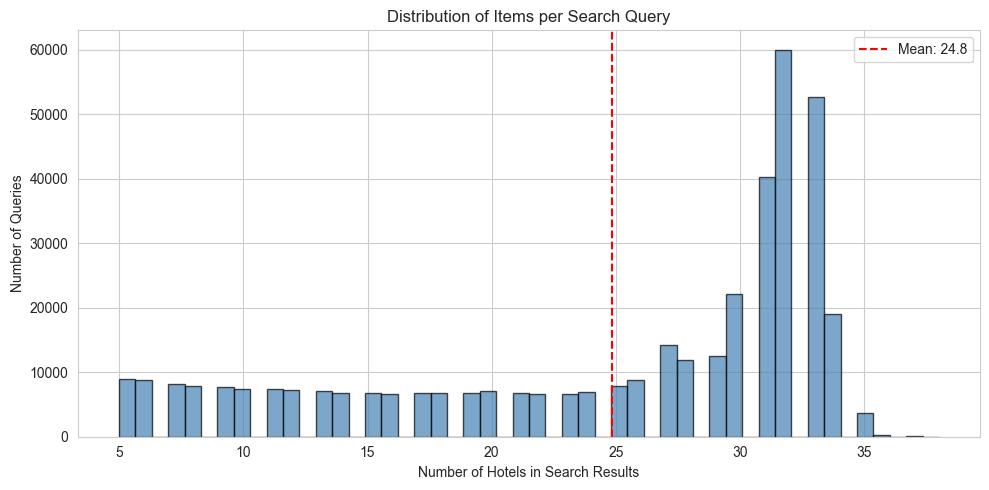

In [5]:
# Distribution of items per query
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(items_per_query, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(items_per_query.mean(), color='red', linestyle='--', label=f'Mean: {items_per_query.mean():.1f}')
ax.set_title('Distribution of Items per Search Query')
ax.set_xlabel('Number of Hotels in Search Results')
ax.set_ylabel('Number of Queries')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Missing Values Analysis

Understanding which columns have missing data and how much is critical for choosing imputation strategies.

In [6]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing_df)} / {len(df.columns)}\n")
missing_df

Columns with missing values: 31 / 54



,missing_count,missing_pct
comp1_rate_percent_diff,9732623,98.14
comp6_rate_percent_diff,9724218,98.05
comp1_rate,9681724,97.62
comp1_inv,9663097,97.43
comp4_rate_percent_diff,9653317,97.34
gross_bookings_usd,9640938,97.21
comp7_rate_percent_diff,9639692,97.20
comp6_rate,9435043,95.14
visitor_hist_starrating,9412233,94.91
visitor_hist_adr_usd,9409918,94.88


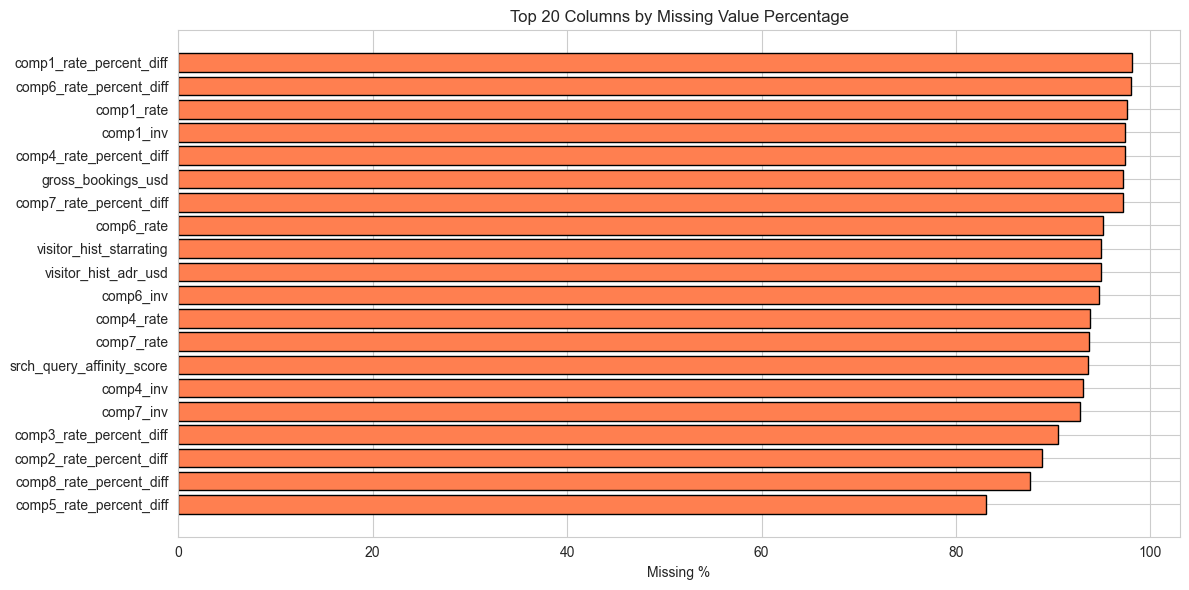

In [7]:
# Visualize missing percentages
fig, ax = plt.subplots(figsize=(12, 6))
top_missing = missing_df.head(20)
ax.barh(top_missing.index, top_missing['missing_pct'], color='coral', edgecolor='black')
ax.set_xlabel('Missing %')
ax.set_title('Top 20 Columns by Missing Value Percentage')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Key observations on missing data:
- **Competitor columns** (`comp1-8_rate`, `comp1-8_inv`, `comp1-8_rate_percent_diff`): High missingness is expected — it means no competitor data was available for that hotel/search. We fill with 0 (neutral).
- **`visitor_hist_starrating`** and **`visitor_hist_adr_usd`**: Missing for first-time visitors with no history. We fill with -1 as a sentinel value.
- **`prop_review_score`**: Missing for unrated properties. Fill with 0.
- **`prop_location_score2`**: Moderate missingness — fill with median.

## 4. Target Variable Analysis

In LTR, the "target" is the relevance of each item. The Expedia dataset provides two signals:
- **`click_bool`**: Did the user click on this hotel? (weak signal)
- **`booking_bool`**: Did the user book this hotel? (strong signal)

A booked item is always also clicked. Let's examine the distribution.

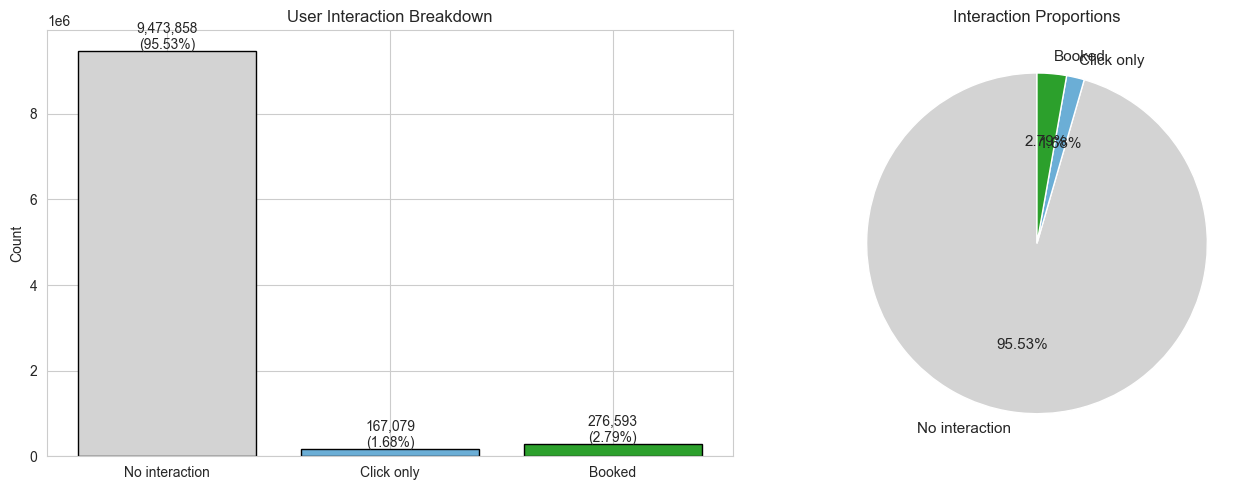


Booking-to-click ratio: 62.34% of clicked items are booked


In [8]:
# Interaction breakdown
no_interaction = ((df[CLICK_BOOL] == 0) & (df[BOOKING_BOOL] == 0)).sum()
click_only = ((df[CLICK_BOOL] == 1) & (df[BOOKING_BOOL] == 0)).sum()
booked = (df[BOOKING_BOOL] == 1).sum()

labels = ['No interaction', 'Click only', 'Booked']
counts = [no_interaction, click_only, booked]
colors = ['#d3d3d3', '#6baed6', '#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(labels, counts, color=colors, edgecolor='black')
for i, (label, count) in enumerate(zip(labels, counts)):
    axes[0].text(i, count + len(df)*0.005, f'{count:,}\n({count/len(df)*100:.2f}%)',
                ha='center', fontsize=10)
axes[0].set_title('User Interaction Breakdown')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts, labels=labels, colors=colors, autopct='%1.2f%%',
           startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Interaction Proportions')

plt.tight_layout()
plt.show()

print(f"\nBooking-to-click ratio: {booked / (click_only + booked):.2%} of clicked items are booked")

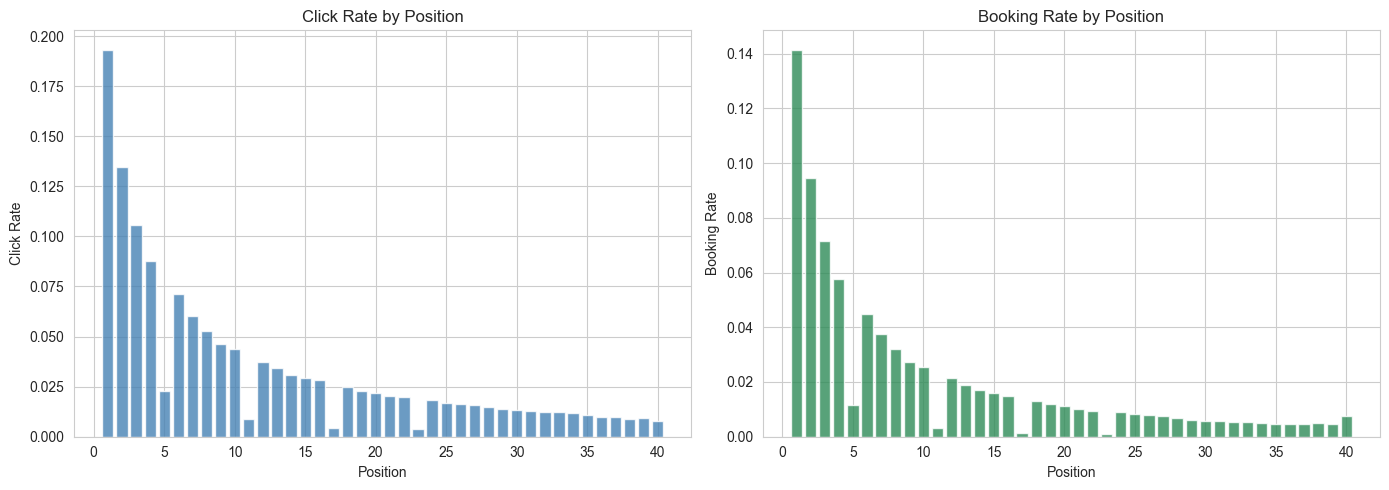

This steep decay is 'position bias' — users click top results more because they SEE them first, not necessarily because they're better.


In [9]:
# Click and booking rates by position
pos_stats = df.groupby(POSITION).agg(
    click_rate=(CLICK_BOOL, 'mean'),
    booking_rate=(BOOKING_BOOL, 'mean'),
    count=(CLICK_BOOL, 'count')
).head(40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(pos_stats.index, pos_stats['click_rate'], color='steelblue', alpha=0.8)
axes[0].set_title('Click Rate by Position')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Click Rate')

axes[1].bar(pos_stats.index, pos_stats['booking_rate'], color='seagreen', alpha=0.8)
axes[1].set_title('Booking Rate by Position')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Booking Rate')

plt.tight_layout()
plt.show()

print("This steep decay is 'position bias' — users click top results more because they SEE them first, not necessarily because they're better.")

## 5. Property Feature Distributions

Let's explore the key hotel features that will drive our ranking model.

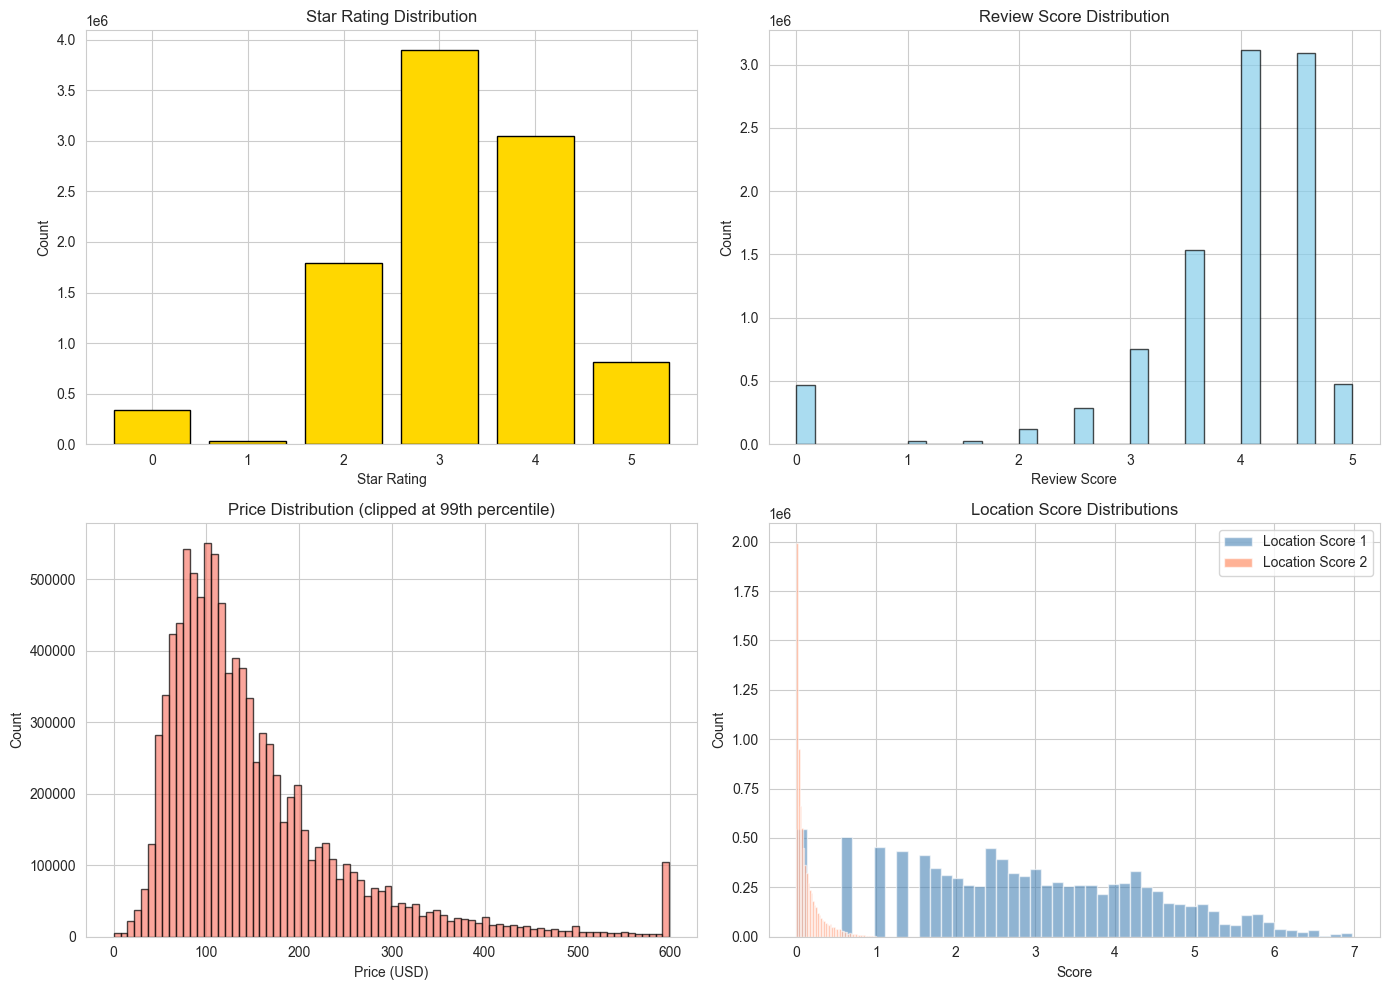

In [10]:
# Star rating distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Star rating
star_counts = df[PROP_STARRATING].value_counts().sort_index()
axes[0, 0].bar(star_counts.index, star_counts.values, color='gold', edgecolor='black')
axes[0, 0].set_title('Star Rating Distribution')
axes[0, 0].set_xlabel('Star Rating')
axes[0, 0].set_ylabel('Count')

# Review score
axes[0, 1].hist(df[PROP_REVIEW_SCORE].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Review Score Distribution')
axes[0, 1].set_xlabel('Review Score')
axes[0, 1].set_ylabel('Count')

# Price
price_clipped = df[PRICE_USD].clip(upper=df[PRICE_USD].quantile(0.99))
axes[1, 0].hist(price_clipped, bins=80, color='salmon', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Price Distribution (clipped at 99th percentile)')
axes[1, 0].set_xlabel('Price (USD)')
axes[1, 0].set_ylabel('Count')

# Location scores
axes[1, 1].hist(df[PROP_LOCATION_SCORE1].dropna(), bins=50, alpha=0.6, label='Location Score 1', color='steelblue')
axes[1, 1].hist(df[PROP_LOCATION_SCORE2].dropna(), bins=50, alpha=0.6, label='Location Score 2', color='coral')
axes[1, 1].set_title('Location Score Distributions')
axes[1, 1].set_xlabel('Score')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

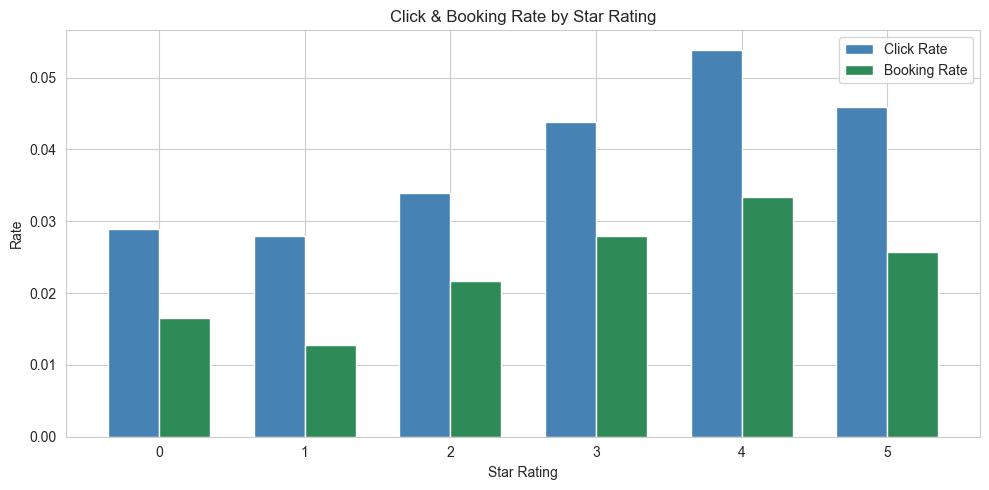

In [11]:
# Click/booking rate by star rating
star_interaction = df.groupby(PROP_STARRATING).agg(
    click_rate=(CLICK_BOOL, 'mean'),
    booking_rate=(BOOKING_BOOL, 'mean'),
    count=(CLICK_BOOL, 'count')
)

fig, ax = plt.subplots(figsize=(10, 5))
x = star_interaction.index
width = 0.35
ax.bar(x - width/2, star_interaction['click_rate'], width, label='Click Rate', color='steelblue')
ax.bar(x + width/2, star_interaction['booking_rate'], width, label='Booking Rate', color='seagreen')
ax.set_title('Click & Booking Rate by Star Rating')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Rate')
ax.legend()
ax.set_xticks(x)
plt.tight_layout()
plt.show()

## 6. Search Context Features

Understanding what users are searching for helps us build context-aware features.

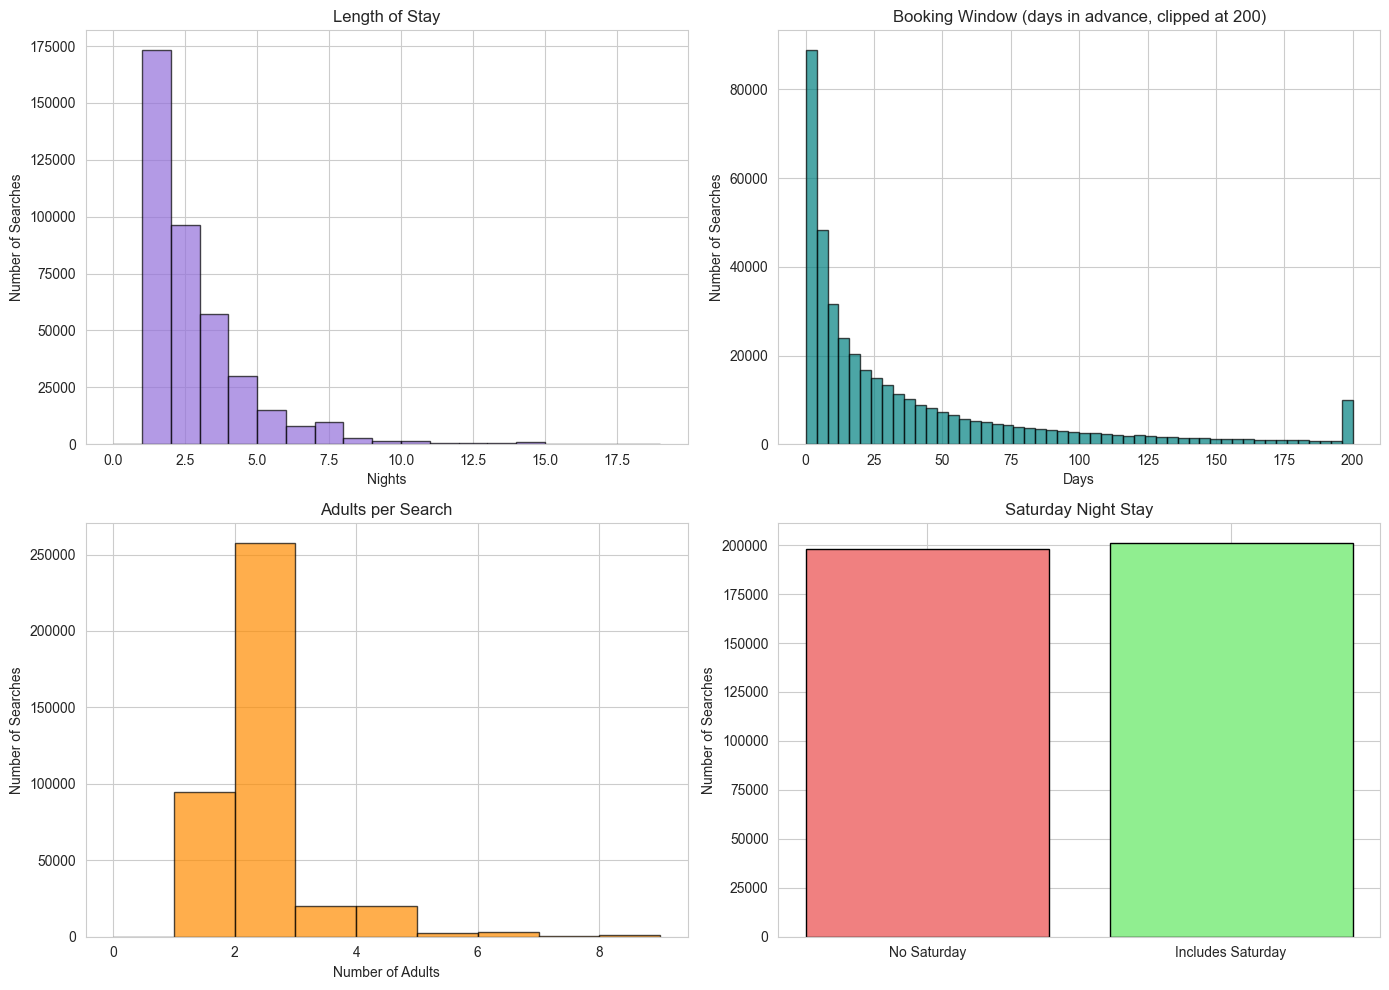

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Length of stay
los = df.drop_duplicates(SEARCH_ID)[SRCH_LENGTH_OF_STAY]
axes[0, 0].hist(los, bins=range(0, 20), color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Length of Stay')
axes[0, 0].set_xlabel('Nights')
axes[0, 0].set_ylabel('Number of Searches')

# Booking window
bw = df.drop_duplicates(SEARCH_ID)[SRCH_BOOKING_WINDOW]
axes[0, 1].hist(bw.clip(upper=200), bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Booking Window (days in advance, clipped at 200)')
axes[0, 1].set_xlabel('Days')
axes[0, 1].set_ylabel('Number of Searches')

# Adults count
adults = df.drop_duplicates(SEARCH_ID)['srch_adults_count']
axes[1, 0].hist(adults, bins=range(0, 10), color='darkorange', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Adults per Search')
axes[1, 0].set_xlabel('Number of Adults')
axes[1, 0].set_ylabel('Number of Searches')

# Saturday night
sat = df.drop_duplicates(SEARCH_ID)['srch_saturday_night_bool'].value_counts()
axes[1, 1].bar(['No Saturday', 'Includes Saturday'], sat.sort_index().values,
              color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[1, 1].set_title('Saturday Night Stay')
axes[1, 1].set_ylabel('Number of Searches')

plt.tight_layout()
plt.show()

## 7. Price Analysis

Price is one of the most important features. Let's look at how it relates to clicks and bookings, and how it varies across queries.

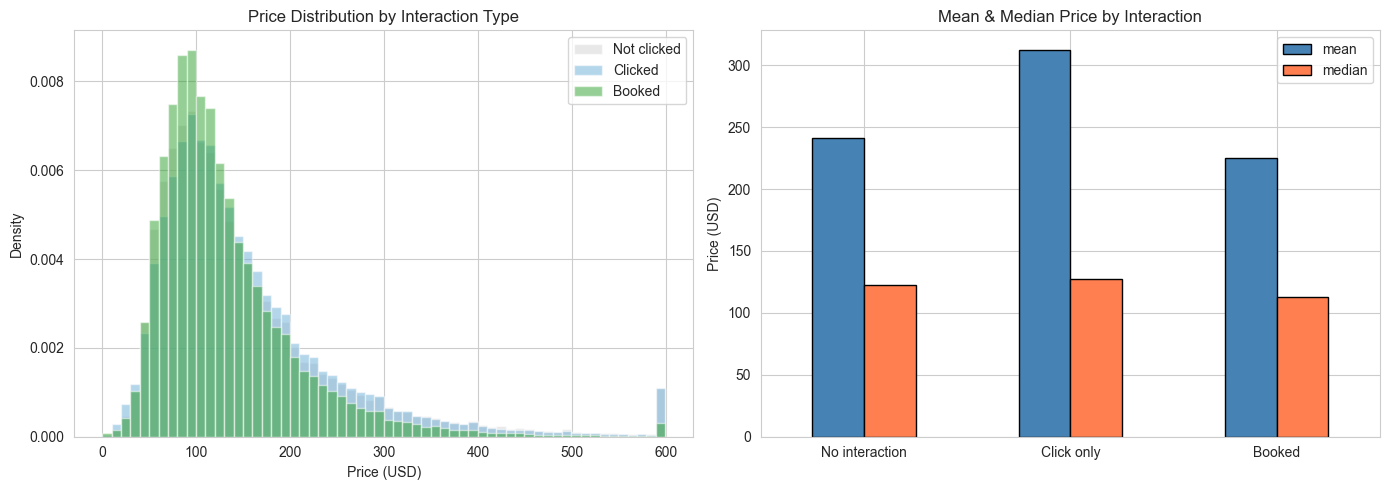

In [13]:
# Price distribution by interaction type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_cap = df[PRICE_USD].quantile(0.99)

# Price of clicked vs not clicked
for label, mask, color in [
    ('Not clicked', df[CLICK_BOOL] == 0, '#d3d3d3'),
    ('Clicked', (df[CLICK_BOOL] == 1) & (df[BOOKING_BOOL] == 0), '#6baed6'),
    ('Booked', df[BOOKING_BOOL] == 1, '#2ca02c'),
]:
    subset = df.loc[mask, PRICE_USD].clip(upper=price_cap)
    axes[0].hist(subset, bins=60, alpha=0.5, label=label, color=color, density=True)

axes[0].set_title('Price Distribution by Interaction Type')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Price statistics by interaction
interaction_prices = df.groupby([CLICK_BOOL, BOOKING_BOOL])[PRICE_USD].agg(['mean', 'median']).round(2)
interaction_prices.index = ['No interaction', 'Click only', 'Booked']
interaction_prices.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('Mean & Median Price by Interaction')
axes[1].set_ylabel('Price (USD)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

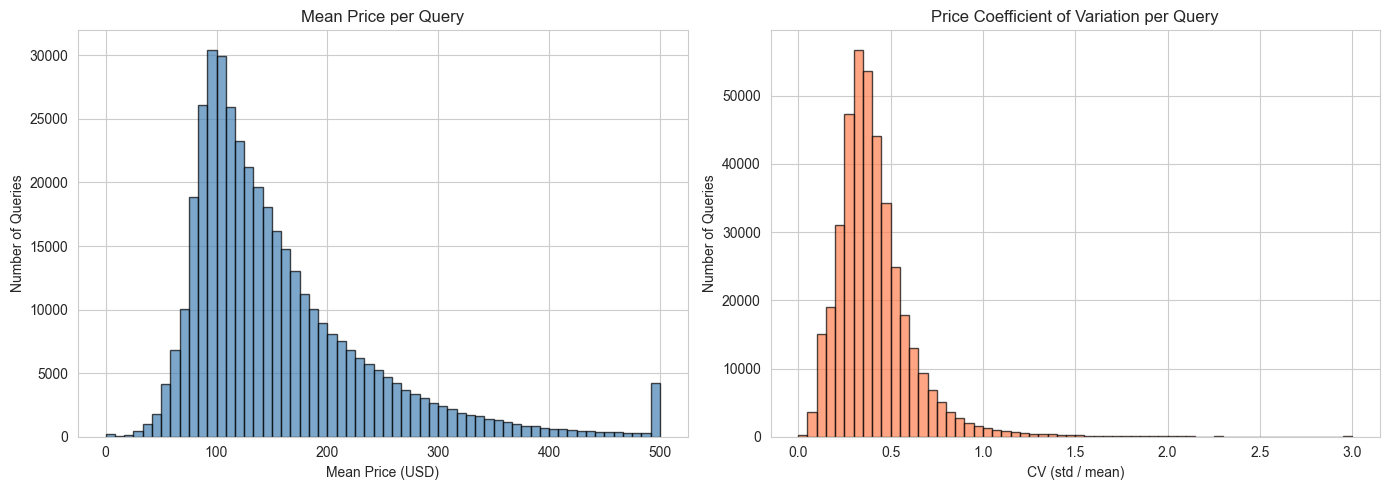

Prices vary widely across queries (different destinations/hotel classes).
This is why relative/match features (price vs query mean) are more useful than raw price.


In [14]:
# Price variation within queries — why relative price matters
query_price_stats = df.groupby(SEARCH_ID)[PRICE_USD].agg(['mean', 'std', 'min', 'max'])
query_price_stats['range'] = query_price_stats['max'] - query_price_stats['min']
query_price_stats['cv'] = query_price_stats['std'] / query_price_stats['mean']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(query_price_stats['mean'].clip(upper=500), bins=60, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Mean Price per Query')
axes[0].set_xlabel('Mean Price (USD)')
axes[0].set_ylabel('Number of Queries')

axes[1].hist(query_price_stats['cv'].clip(upper=3).dropna(), bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Price Coefficient of Variation per Query')
axes[1].set_xlabel('CV (std / mean)')
axes[1].set_ylabel('Number of Queries')

plt.tight_layout()
plt.show()

print("Prices vary widely across queries (different destinations/hotel classes).")
print("This is why relative/match features (price vs query mean) are more useful than raw price.")

## 8. Promotion & Brand Analysis

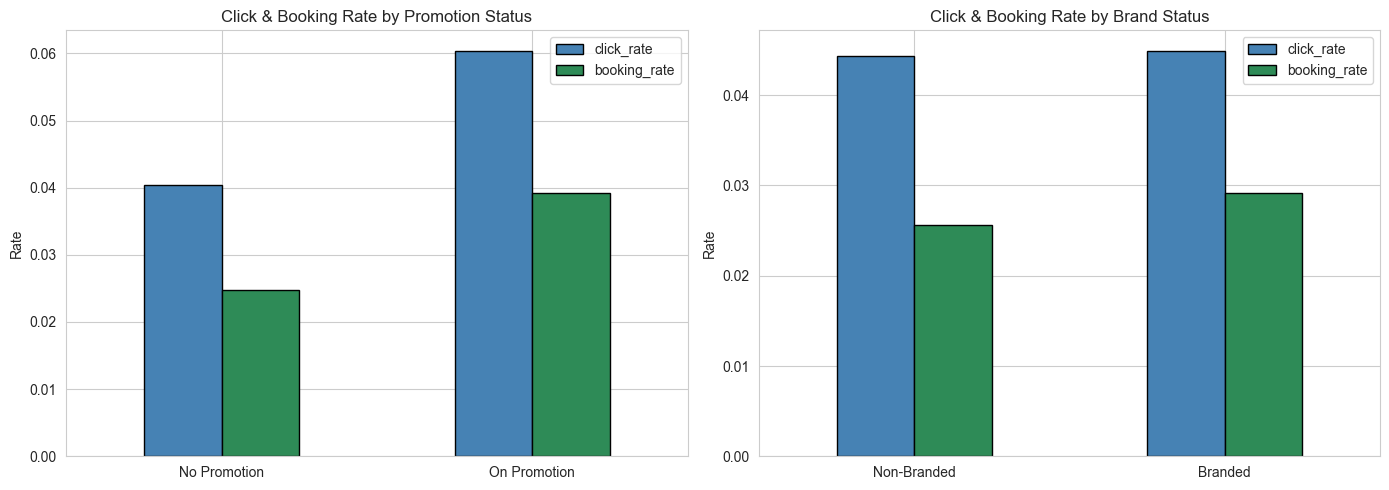

In [15]:
# Promotion and brand effects
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Promotion effect
promo_stats = df.groupby(PROMOTION_FLAG).agg(
    click_rate=(CLICK_BOOL, 'mean'),
    booking_rate=(BOOKING_BOOL, 'mean'),
)
promo_stats.index = ['No Promotion', 'On Promotion']
promo_stats.plot(kind='bar', ax=axes[0], color=['steelblue', 'seagreen'], edgecolor='black')
axes[0].set_title('Click & Booking Rate by Promotion Status')
axes[0].set_ylabel('Rate')
axes[0].tick_params(axis='x', rotation=0)

# Brand effect
brand_stats = df.groupby(PROP_BRAND_BOOL).agg(
    click_rate=(CLICK_BOOL, 'mean'),
    booking_rate=(BOOKING_BOOL, 'mean'),
)
brand_stats.index = ['Non-Branded', 'Branded']
brand_stats.plot(kind='bar', ax=axes[1], color=['steelblue', 'seagreen'], edgecolor='black')
axes[1].set_title('Click & Booking Rate by Brand Status')
axes[1].set_ylabel('Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 9. Competitor Data Overview

The dataset includes rate and inventory comparisons against 8 competitors. Let's see how often this data is available and what it tells us.

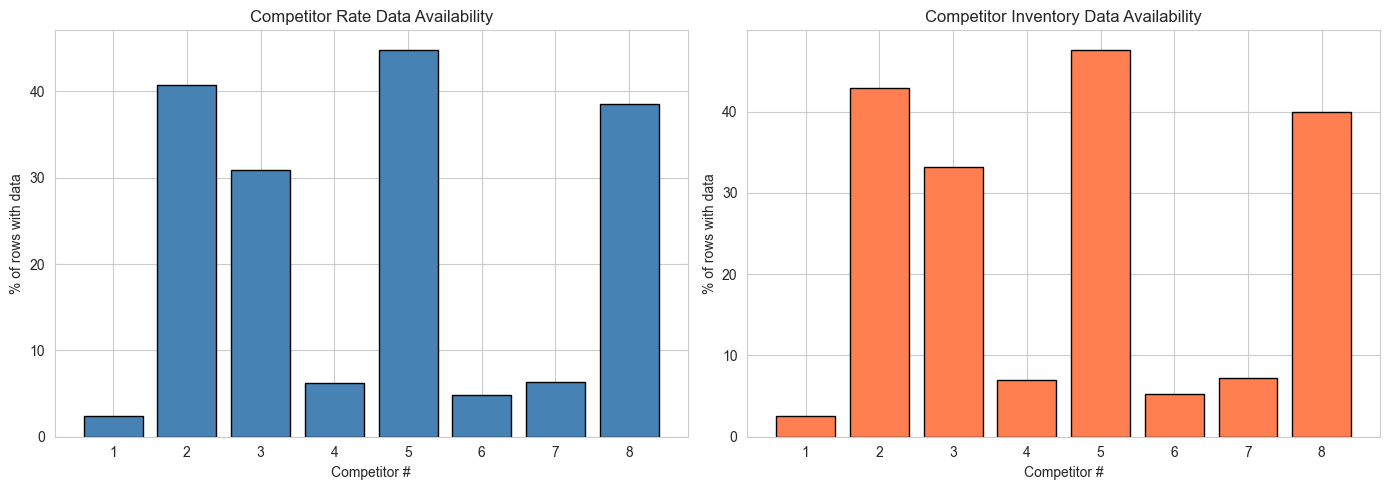


Competitor rate values (when available):
  -1 (competitor cheaper): 1,954,361
   0 (same rate):          13,063,322
   1 (competitor more expensive): 2,315,029


In [16]:
# Competitor data availability
from hotel_ranker.data.schema import COMPETITOR_RATE_COLS, COMPETITOR_INV_COLS

comp_rate_available = {col: df[col].notna().mean() * 100 for col in COMPETITOR_RATE_COLS if col in df.columns}
comp_inv_available = {col: df[col].notna().mean() * 100 for col in COMPETITOR_INV_COLS if col in df.columns}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(comp_rate_available)+1),
           list(comp_rate_available.values()), color='steelblue', edgecolor='black')
axes[0].set_title('Competitor Rate Data Availability')
axes[0].set_xlabel('Competitor #')
axes[0].set_ylabel('% of rows with data')
axes[0].set_xticks(range(1, 9))

axes[1].bar(range(1, len(comp_inv_available)+1),
           list(comp_inv_available.values()), color='coral', edgecolor='black')
axes[1].set_title('Competitor Inventory Data Availability')
axes[1].set_xlabel('Competitor #')
axes[1].set_ylabel('% of rows with data')
axes[1].set_xticks(range(1, 9))

plt.tight_layout()
plt.show()

# When competitor rate data IS available, what does it show?
rate_cols_present = [c for c in COMPETITOR_RATE_COLS if c in df.columns]
if rate_cols_present:
    rate_values = df[rate_cols_present].stack()
    val_counts = rate_values.value_counts().sort_index()
    print("\nCompetitor rate values (when available):")
    print("  -1 (competitor cheaper):", f"{(rate_values == -1).sum():,}")
    print("   0 (same rate):         ", f"{(rate_values == 0).sum():,}")
    print("   1 (competitor more expensive):", f"{(rate_values == 1).sum():,}")

## 10. Feature Correlations with Target

Let's check which raw features have the strongest relationship with clicks and bookings.

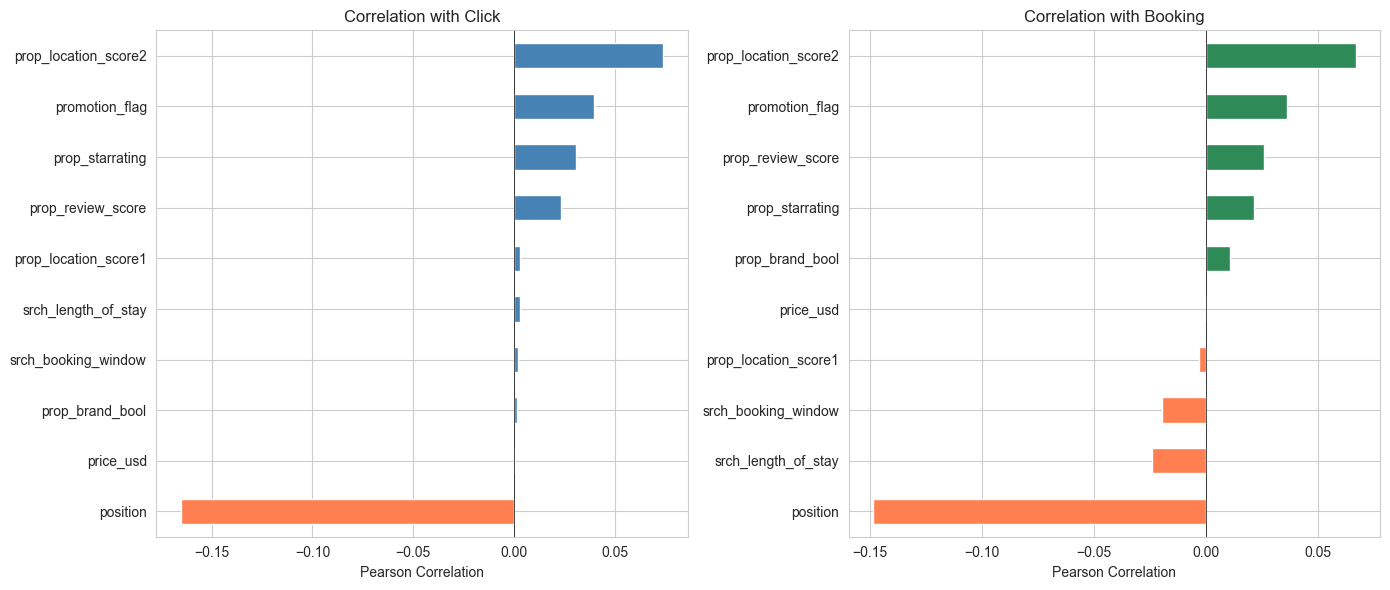


Key insights:
- Position has the strongest (negative) correlation — position bias!
- This is why we need IPS: raw correlations are confounded by position.


In [17]:
# Correlation of numeric features with click and booking
feature_cols = [
    PROP_STARRATING, PROP_REVIEW_SCORE, PROP_BRAND_BOOL,
    PROP_LOCATION_SCORE1, PROP_LOCATION_SCORE2,
    PRICE_USD, PROMOTION_FLAG, SRCH_LENGTH_OF_STAY,
    SRCH_BOOKING_WINDOW, POSITION,
]
available_cols = [c for c in feature_cols if c in df.columns]

corr_click = df[available_cols].corrwith(df[CLICK_BOOL]).sort_values()
corr_book = df[available_cols].corrwith(df[BOOKING_BOOL]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr_click.plot(kind='barh', ax=axes[0], color=['coral' if v < 0 else 'steelblue' for v in corr_click])
axes[0].set_title('Correlation with Click')
axes[0].set_xlabel('Pearson Correlation')
axes[0].axvline(0, color='black', linewidth=0.5)

corr_book.plot(kind='barh', ax=axes[1], color=['coral' if v < 0 else 'seagreen' for v in corr_book])
axes[1].set_title('Correlation with Booking')
axes[1].set_xlabel('Pearson Correlation')
axes[1].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nKey insights:")
print("- Position has the strongest (negative) correlation — position bias!")
print("- This is why we need IPS: raw correlations are confounded by position.")

## 11. Numerical Summary Statistics

In [18]:
df[available_cols + [CLICK_BOOL, BOOKING_BOOL]].describe().round(3)

,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,price_usd,promotion_flag,srch_length_of_stay,srch_booking_window,position,click_bool,booking_bool
count,9917530.000,9902900.000,9917530.000,9917530.000,7739150.000,9.917530e+06,9917530.000,9917530.000,9917530.000,9917530.000,9917530.000,9917530.000
mean,3.182,3.778,0.634,2.876,0.130,2.417830e+02,0.216,2.390,37.624,16.866,0.045,0.028
std,1.050,1.051,0.482,1.532,0.160,1.434181e+04,0.411,2.067,52.108,10.428,0.207,0.165
min,0.000,0.000,0.000,0.000,0.000,0.000000e+00,0.000,1.000,0.000,1.000,0.000,0.000
25%,3.000,3.500,0.000,1.790,0.019,8.500000e+01,0.000,1.000,4.000,8.000,0.000,0.000
50%,3.000,4.000,1.000,2.770,0.069,1.220700e+02,0.000,2.000,17.000,16.000,0.000,0.000
75%,4.000,4.500,1.000,4.040,0.181,1.850000e+02,0.000,3.000,49.000,26.000,0.000,0.000
max,5.000,5.000,1.000,6.980,1.000,1.972633e+07,1.000,59.000,498.000,40.000,1.000,1.000


## 12. Key Takeaways

1. **Highly imbalanced targets**: Only ~5% of items get clicked, ~1-2% get booked. This motivates a multi-objective label (clicks + bookings weighted by revenue).

2. **Strong position bias**: Click/booking rates decay steeply with position. We must use Inverse Propensity Scoring (IPS) to correct for this during training.

3. **Price is relative**: Raw price means little without context. A $150 hotel is cheap in NYC but expensive in rural areas. Match features (price vs query mean) are essential.

4. **Sparse competitor data**: Competitor columns have 50-80% missing values. We fill with 0 (neutral) since missing = no competitor info.

5. **Visitor history is sparse**: ~70% of searches lack visitor history. The `-1` sentinel lets the model learn to handle first-time users.

6. **Randomized placement data**: The `random_bool` flag provides a natural experiment for unbiased propensity estimation.

### Next Steps
- **Notebook 02**: Build and explore engineered features
- **Notebook 03**: Analyze and correct position bias with IPS
- **Notebook 04**: Train the LGBMRanker model
- **Notebook 05**: Evaluate ranking quality